In [2]:
from kafka import KafkaConsumer, TopicPartition
import json
import numpy as np
import matplotlib.mlab as mlab
from sklearn.ensemble import IsolationForest
import os
import time
from copy import deepcopy
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from collections import defaultdict
from baskervillehall.baskervillehall_isolation_forest import BaskervillehallIsolationForest
from baskervillehall.baskervillehall_isolation_forest import ModelType
from baskervillehall.feature_extractor import FeatureExtractor

plt.rcParams["figure.figsize"] = (15,5)

In [3]:
import logging
import sys
logger = logging.getLogger('pca')
logger.addHandler(logging.StreamHandler())
logger.addHandler(logging.StreamHandler(sys.stdout))
logger.setLevel('DEBUG')
os.environ['S3_ACCESS'] = 'c490f17bdb784fa08f4d11836ee18e48'
os.environ['S3_SECRET'] = 'e4b65e27b3734d0d96ce6038586ef43f'
os.environ['S3_ENDPOINT'] = 's3.gra.cloud.ovh.net'
os.environ['S3_REGION'] = 'GRA'

In [4]:
kafka_url = ['kafka9-0.kafka9-headless.default.svc.cluster.local:9093','kafka9-1.kafka9-headless.default.svc.cluster.local:9093','kafka9-2.kafka9-headless.default.svc.cluster.local:9093']
# kafka_url = ['kafkab-0.kafkab-headless.default.svc.cluster.local:9093','kafkab-1.kafkab-headless.default.svc.cluster.local:9093','kafka9-b.kafkab-headless.default.svc.cluster.local:9093']

In [5]:
partitions = {
    'vytoki.net': 0,
    'zhitomir.info': 1,
    'urban-pushkino.ru': 0,
    'dev.emawpb.org': 0,
    'palestinechronicle.com': 1,
    'equalit.ie': 0,
    'lexota.org': 0,
    'kavkaz-uzel.eu': 0,
    'amp.kavkaz-uzel.eu': 2,
    'indymedia.nl': 0,
    'btselem.org': 0,
    'verafiles.org': 1,
    'telegraf.in.ua': 2,
    'gubernia.com': 1,
    'informator.ua': 0,
    'culturesofresistance.org': 2,
    'zmina.info': 1,
    'memex.craphound.com': 2
}

In [6]:
# host = 'kl.informator.ua'
host = 'verafiles.org'
# host = 'zhitomir.info'
# host = 'deflect.ca'
# host = 'btselem.org'
# host = 'nswp.org'
# host = 'indymedia.nl'
# host = 'urban-pushkino.ru'
# host = 'verafiles.org'
# host = 'zmina.info'
# host = 'memex.craphound.com'

dataset_size = 1000
datetime_format = '%Y-%m-%d %H:%M:%S'
# features = [
#             'request_rate',
#             'post_rate',
#             'request_interval_average',
#             'request_interval_std',
#             'response4xx_to_request_ratio',
#             'response5xx_to_request_ratio',
#             'top_page_to_request_ratio',
#             'unique_path_rate',
#             'unique_path_to_request_ratio',
#             'unique_query_rate',
#             'unique_query_to_unique_path_ratio',
#             'image_to_html_ratio',
#             'js_to_html_ratio',
#             'css_to_html_ratio',
#             'path_depth_average',
#             'path_depth_std',
#             'payload_size_log_average',
#             'entropy',
#             'num_requests',
#             'duration',
#             'edge_entropy',
#             'static_ratio',
#             'ua_entropy',
#             # 'pca'
# ]

In [7]:
features = [
    'request_rate',
    'post_rate',
    'request_interval_average',
    'request_interval_std',
    'response4xx_to_request_ratio',
    'top_page_to_request_ratio',
    'unique_path_rate',
    'unique_path_to_request_ratio',
    'unique_query_rate',
    'unique_query_to_unique_path_ratio',
    'image_to_html_ratio',
    'js_to_html_ratio',
    'css_to_html_ratio',
    'path_depth_average',
    'path_depth_std',
    'payload_size_log_average',
    'entropy',
    'edge_count',
    'static_ratio',
    'ua_count',
    'api_ratio',
    'num_ciphers',
    # 'ua_score'
    # 'num_languages'
]
categorical_features=[
    # 'country',
    'primary_session',
    'cipher',
    # 'asset_only',
    # 'valid_browser_ciphers',
    # 'weak_cipher',
    # 'headless_ua',
    # 'datacenter_asn'
]
all_features = features + categorical_features

In [8]:
topic = 'BASKERVILLEHALL_4'
# topic = 'logstash_deflect.log'
# topic = 'STATS_WEBLOGS_5M'
# topic = 'anton31'

In [46]:
def read_dataset(size=1000, topic=''):
    consumer = KafkaConsumer(
        bootstrap_servers=kafka_url,
        group_id='anton11'
    )
    
    num = 0    
    print(f'Reading from kafka ...')
    time_now = int(time.time())
    sessions = []
    labels = []

    consumer.assign([
        TopicPartition(topic, 0),
        TopicPartition(topic, 1),
        TopicPartition(topic, 2),
    ])
    consumer.seek_to_beginning()
    complete = False
    while not complete:
        raw_messages = consumer.poll(timeout_ms=1000, max_records=100)

        for topic_partition, messages in raw_messages.items():
            for message in messages:
                # prevent from getting messages too close to the current time
                time_diff_in_minutes = (time_now - message.timestamp / 1000) / 60
                if time_diff_in_minutes < 2:
                    print(f'{time_diff_in_minutes} minutes. Topic offset is too close to the current times...')
                    complete = True
                    break
                
                if message.value is None :
                    continue
                if message.key is None:
                    continue

                session = json.loads(message.value.decode("utf-8"))
                if session['primary_session']:
                    continue
                if session['duration'] <= 5:
                    continue

                # if session['ai_bot_ua']:
                #     labels.append(1)
                # else:
                #     labels.append(0)
                # sessions.append(session)

                if session['human']:
                    sessions.append(session)
                    labels.append(0)
                elif not session['bad_bot']:
                    sessions.append(session)
                    labels.append(1)
                else:
                    continue
                        
                if len(sessions) == 0:
                    print(f'First session start = {session["start"]} end = {session["end"]}')

                if num == size:
                    complete = True
                    break
                num += 1
                if num % 1000 == 0:
                    print(f'{num} sessions read', session['end'], message.timestamp)
            
    return sessions, labels

In [47]:
sessions, labels = read_dataset(size=200000, topic=topic)
print('Done.')

Reading from kafka ...
1000 sessions read 2025-04-21 06:10:56 1745215860203
2000 sessions read 2025-04-21 04:48:03 1745210886307
3000 sessions read 2025-04-21 04:55:02 1745211305692
4000 sessions read 2025-04-21 05:15:05 1745212509539
5000 sessions read 2025-04-21 05:08:47 1745212131575
6000 sessions read 2025-04-21 06:36:46 1745217408258
7000 sessions read 2025-04-21 06:41:43 1745217706017
8000 sessions read 2025-04-21 05:51:42 1745214705541
9000 sessions read 2025-04-21 06:53:42 1745218426225
10000 sessions read 2025-04-21 05:41:16 1745214078682
11000 sessions read 2025-04-21 06:13:49 1745216032280
12000 sessions read 2025-04-21 06:23:12 1745216598239
13000 sessions read 2025-04-21 06:00:23 1745215228917
14000 sessions read 2025-04-21 07:18:39 1745219922562
15000 sessions read 2025-04-21 07:22:39 1745220163510
16000 sessions read 2025-04-21 06:16:20 1745216184316
17000 sessions read 2025-04-21 07:04:43 1745219088219
18000 sessions read 2025-04-21 07:13:34 1745219618224
19000 sessions

In [48]:
print(f'Total = {len(sessions)}, Bots = {np.sum(labels)}')

Total = 178355, Bots = 86798


In [49]:
fe = FeatureExtractor(features=features, categorical_features=categorical_features)
Z_train = np.array(fe.fit_transform(sessions))


In [50]:
Z_train.shape

(178355, 24)

In [51]:
Z_labels = np.array(labels)
Z_labels.shape

(178355,)

In [52]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Split your data
X_train, X_val, y_train, y_val = train_test_split(Z_train, Z_labels, test_size=0.2, random_state=42, stratify=Z_labels)

# 2. Initialize the model
model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    max_depth=9,
    learning_rate=0.1,
    n_estimators=400,
    subsample=0.9,
    colsample_bytree=0.8,
    random_state=666
)

import pandas as pd

X_train = pd.DataFrame(X_train, columns=all_features)
X_val = pd.DataFrame(X_val, columns=all_features)

# 3. Train the model
model.fit(X_train, y_train)

/opt/conda/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [08:33:18] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=9, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

In [53]:
# 4. Make predictions
y_pred = model.predict(X_val)
y_proba = model.predict_proba(X_val)[:, 1]

In [54]:
# 5. Evaluate
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

Confusion Matrix:
[[17725   586]
 [ 3660 13700]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.97      0.89     18311
           1       0.96      0.79      0.87     17360

    accuracy                           0.88     35671
   macro avg       0.89      0.88      0.88     35671
weighted avg       0.89      0.88      0.88     35671



In [55]:
print(f"\nROC AUC Score: {roc_auc_score(y_val, y_proba):.4f}")


ROC AUC Score: 0.9280


In [56]:
df = pd.DataFrame(Z_train, columns=all_features)
train_prediction = model.predict(df)
train_prediction_proba = model.predict_proba(df)[:, 1]

In [61]:
for i in range(len(sessions)):
    if train_prediction[i] == 1 and labels[i] == 0:
        if(train_prediction_proba[i] < 0.9):
            continue
        print(train_prediction_proba[i])
        print(sessions[i]['ua'])
        print(sessions[i]['asn'])
        print(sessions[i]['ciphers'])
        for r in sessions[i]['requests']:
            print(r['ts'], r['url'])
        for f, v in zip(all_features, Z_train[i]):
            print(f,v)
        print('*************\n\n')
        break

0.94054276
Mozilla/5.0 (Linux; arm_64; Android 14; SM-S918B) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/132.0.6834.33 YaBrowser/25.3.0.33.00 SA/3 Mobile Safari/537.36
42560
['0xaaaa', 'TLS_AES_128_GCM_SHA256', 'TLS_AES_256_GCM_SHA384', 'TLS_CHACHA20_POLY1305_SHA256', 'ECDHE-ECDSA-AES128-GCM-SHA256', 'ECDHE-RSA-AES128-GCM-SHA256', 'ECDHE-ECDSA-AES256-GCM-SHA384', 'ECDHE-RSA-AES256-GCM-SHA384', 'ECDHE-ECDSA-CHACHA20-POLY1305', 'ECDHE-RSA-CHACHA20-POLY1305', 'ECDHE-RSA-AES128-SHA', 'ECDHE-RSA-AES256-SHA', 'AES128-GCM-SHA256', 'AES256-GCM-SHA384', 'AES128-SHA', 'AES256-SHA']
2025-04-21 06:30:38 /var/obc/cache/public/stylesheets/0a0b44d1733c2bc8cf85650b2c464711_all.css
2025-04-21 06:30:38 /var/obc/cache/public/javascript/a3120cb03c4a5ccb092a221a77d67e2e.js
2025-04-21 06:30:38 /extension/resp/design/resp_www/images/googleplus_32.png
2025-04-21 06:30:38 /extension/resp/design/resp_www/images/facebook_32.png
2025-04-21 06:30:38 /extension/resp/design/resp_www/images/nav-logo.png
2025-04-21 

## Shapley 

In [58]:
import shap
import matplotlib.pyplot as plt

# Create TreeExplainer for your model
explainer = shap.Explainer(model)

# Compute SHAP values for validation set
shap_values = explainer(X_val)

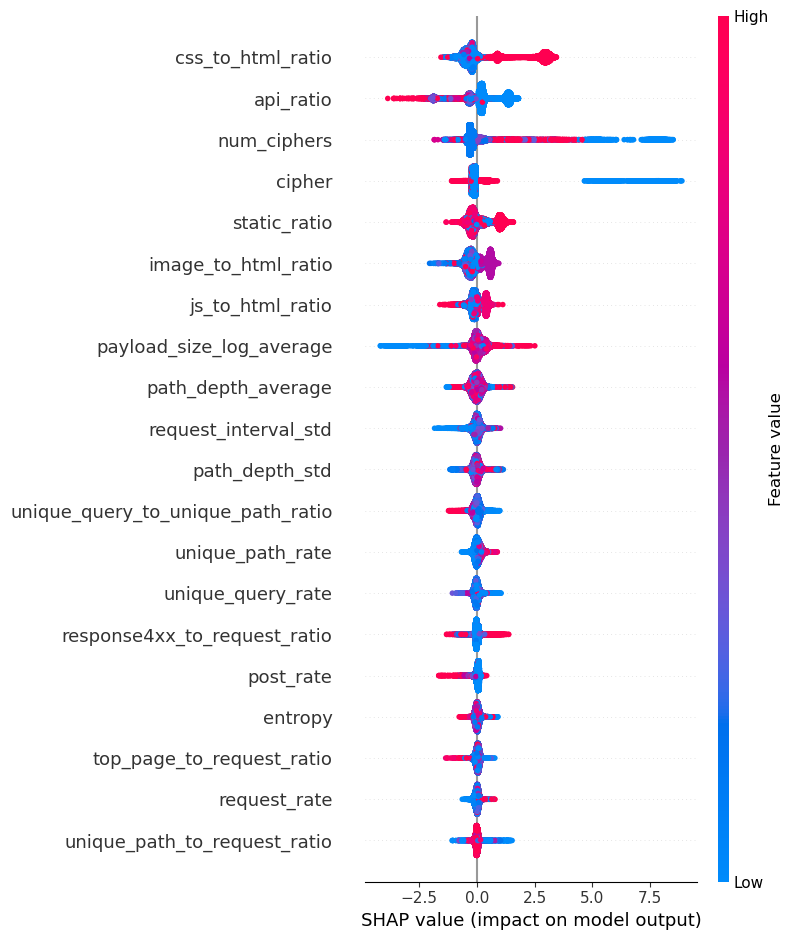

In [59]:
shap.summary_plot(shap_values, X_val, show=True)

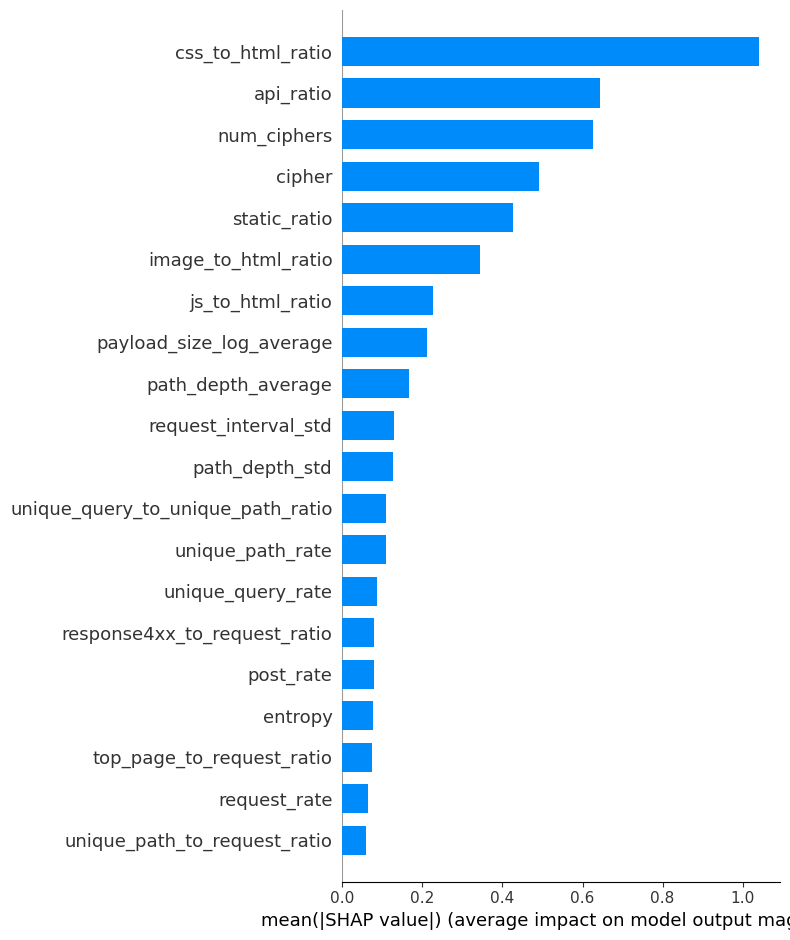

In [60]:
shap.summary_plot(shap_values, X_val, plot_type="bar", show=True)

## Home page

In [140]:
sessions[10]['human']

True

In [141]:
duration = 60
hit_rate = 2
country = 'RU'
session = {
    'duration': duration, 
    'country': country, 
    'primary_session': False, 
    'cipher': 'TLS_CHACHA20_POLY1305_SHA256',
    'human': True,
    'session_id':'-'}
requests = []
num_hits = int(duration * hit_rate / 60)
ts = datetime.now()
time_increment = 60.0 / hit_rate

for i in range(num_hits):
    requests.append({'ts': ts, 
                     'url': sessions[10]['requests'][0]['url'],
                     # 'url': '/', 
                     # 'url': f'{i%3}',
                     'query': f'{i}', 
                     # 'ua': 'ddd',
                     'ua': f'{i}-mozilla/5.0 (compatible; msie 9.0; windows; u; windows nt 6.2;; en-us trident/5.0)',
                     'code': 200, 
                     'type': 'text/html',
                     'method': 'GET',
                     'payload': 100})
    ts += timedelta(seconds=time_increment)
session['requests'] = requests


print('Isolation Forest')
ts = datetime.now()
score, shapley = model.transform([session])
print(f'timer = {(datetime.now()-ts).total_seconds()}')
print(f'hits={len(session["requests"])}')
print(f'Score = {score}')
for sv in get_shapley_features(model, shapley[0]):
    print(f'{sv[1]:.2f} : {sv[0]} --> {sv[2]:.2f}')


Isolation Forest
timer = 0.147125
hits=2
Score = [-0.07377242]
-1.62 : cipher --> 2.00
-1.42 : ua_count --> 2.00
-1.07 : unique_query_to_unique_path_ratio --> 2.00
-0.84 : top_page_to_request_ratio --> 1.00
-0.73 : unique_path_to_request_ratio --> 0.50
-0.61 : static_ratio --> 0.00
-0.42 : payload_size_log_average --> 4.62
-0.41 : request_interval_average --> 15.00
-0.40 : path_depth_average --> 2.00
-0.35 : entropy --> -2.00
-0.33 : request_interval_std --> 15.00
-0.27 : path_depth_std --> 0.00
-0.11 : num_ciphers --> 0.00
-0.08 : css_to_html_ratio --> 0.00
-0.08 : js_to_html_ratio --> 0.00
-0.06 : image_to_html_ratio --> 0.00


In [142]:
Z = np.array(fe.transform([session]))

In [143]:
sessions[1]['duration'], len(sessions[1]['requests'])

(24.0, 6)

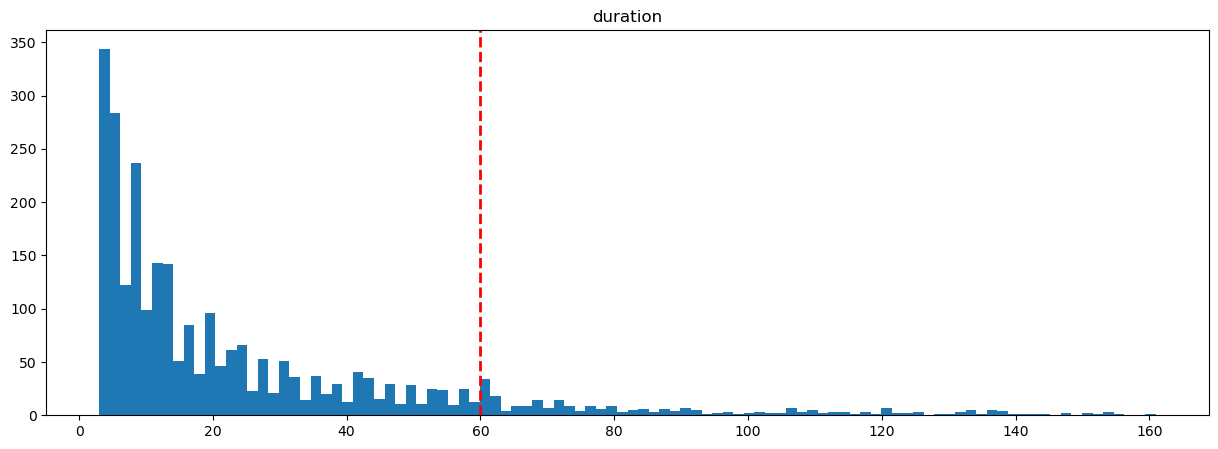

In [144]:
durations = [s['duration'] for s in sessions]
a = np.hstack(durations)
_ = plt.hist(a, bins=100)  
plt.title('duration')
plt.axvline(session['duration'], color='red', linestyle='dashed', linewidth=2)
plt.show()

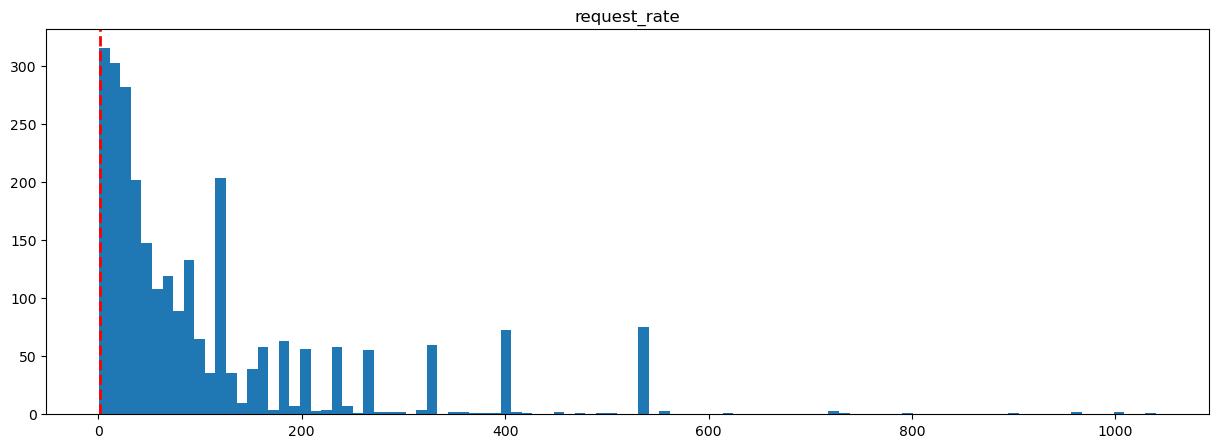

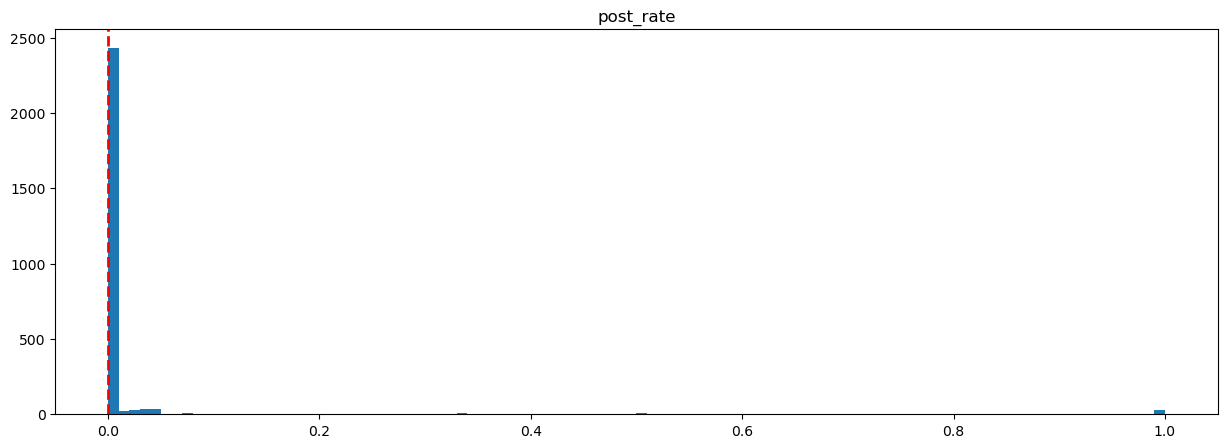

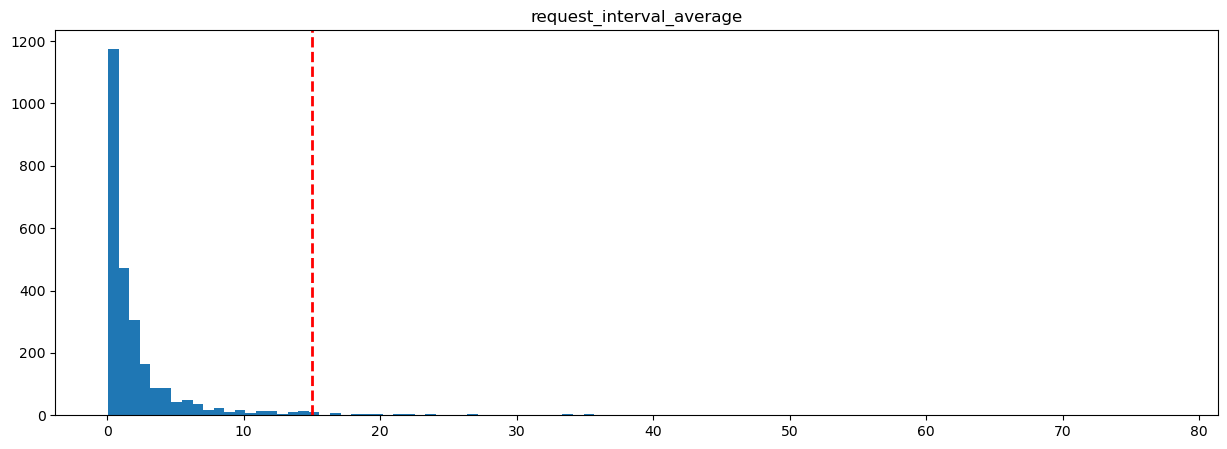

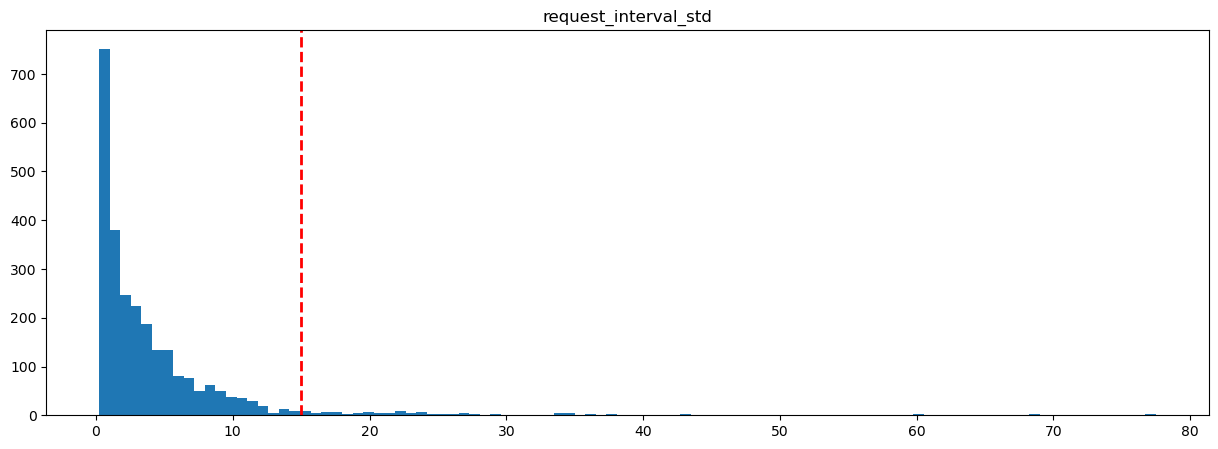

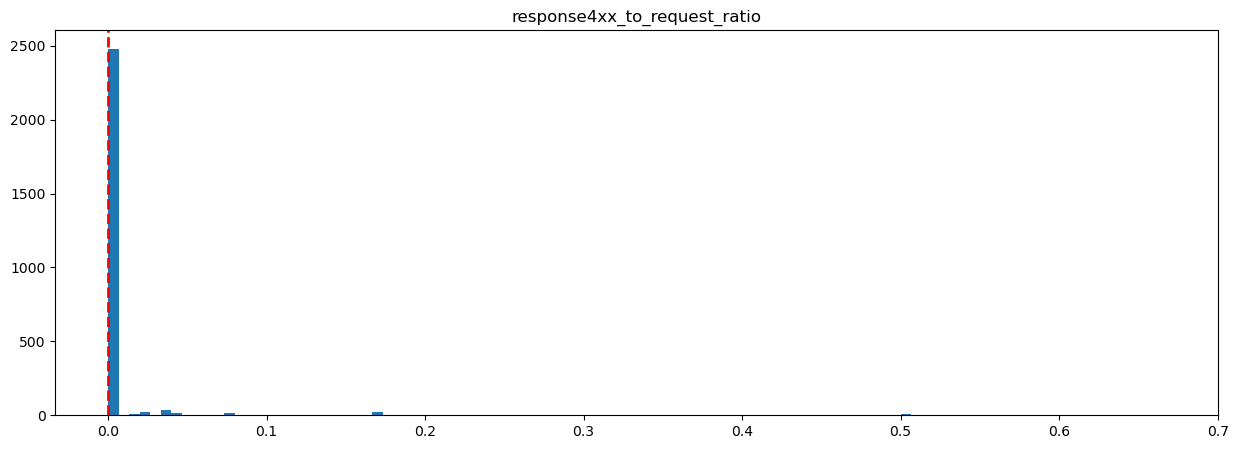

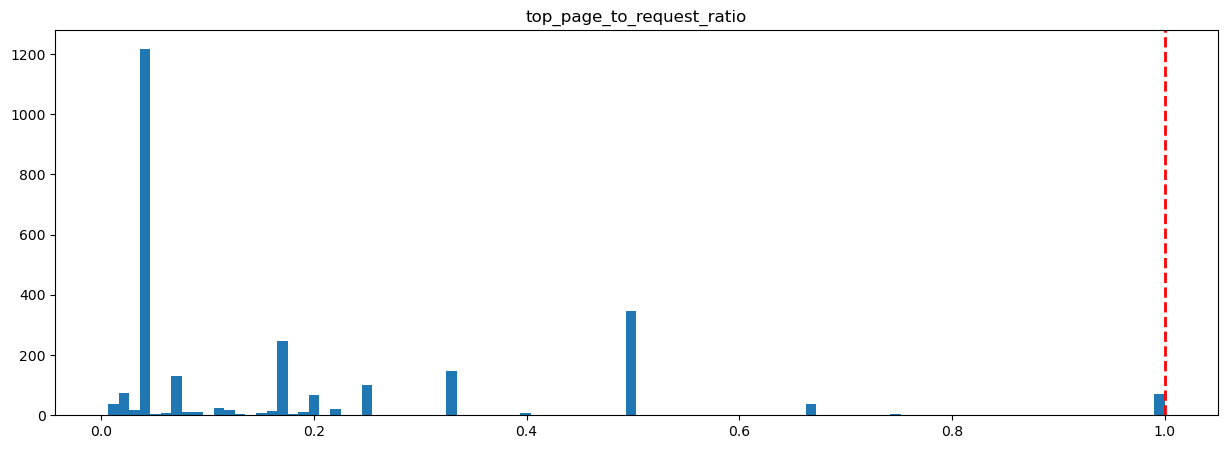

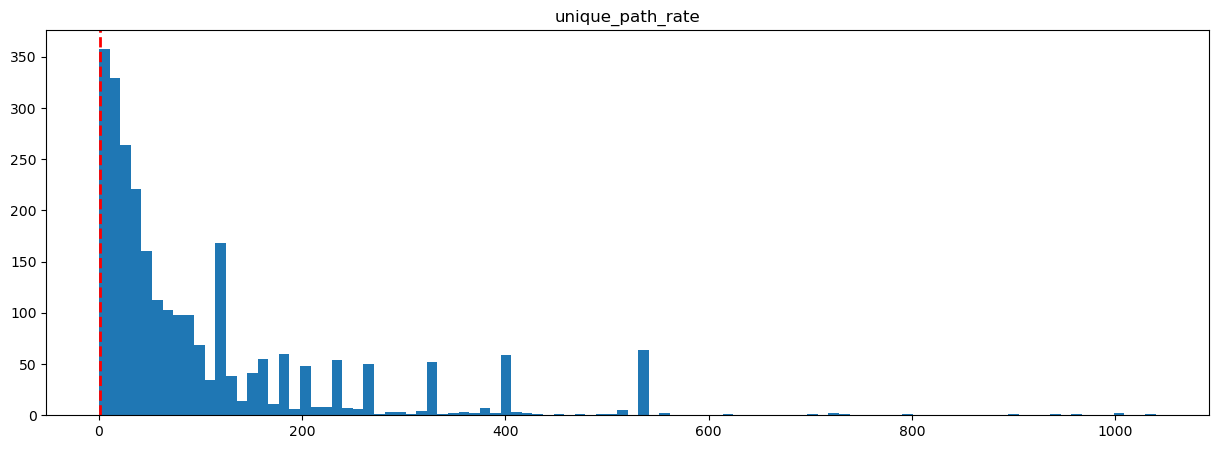

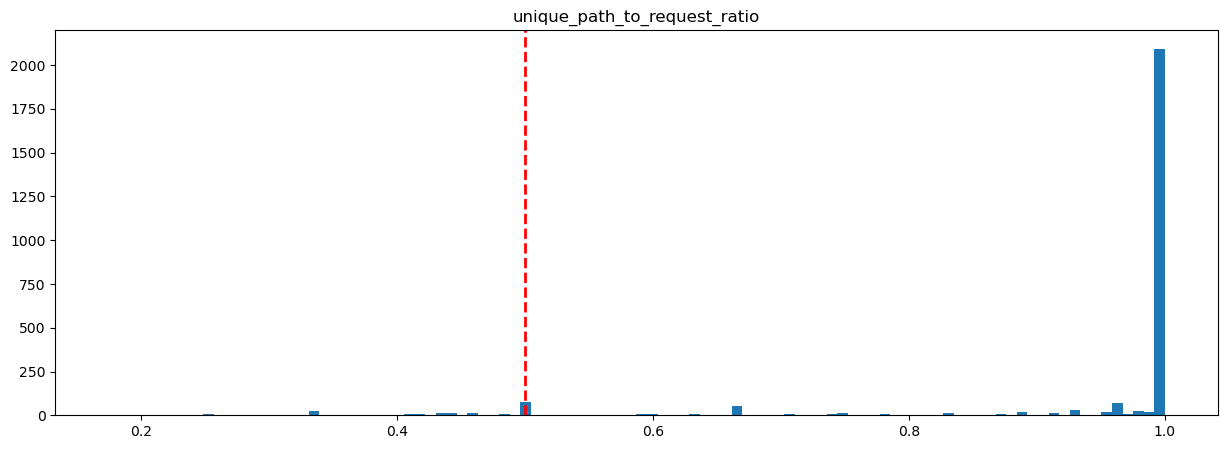

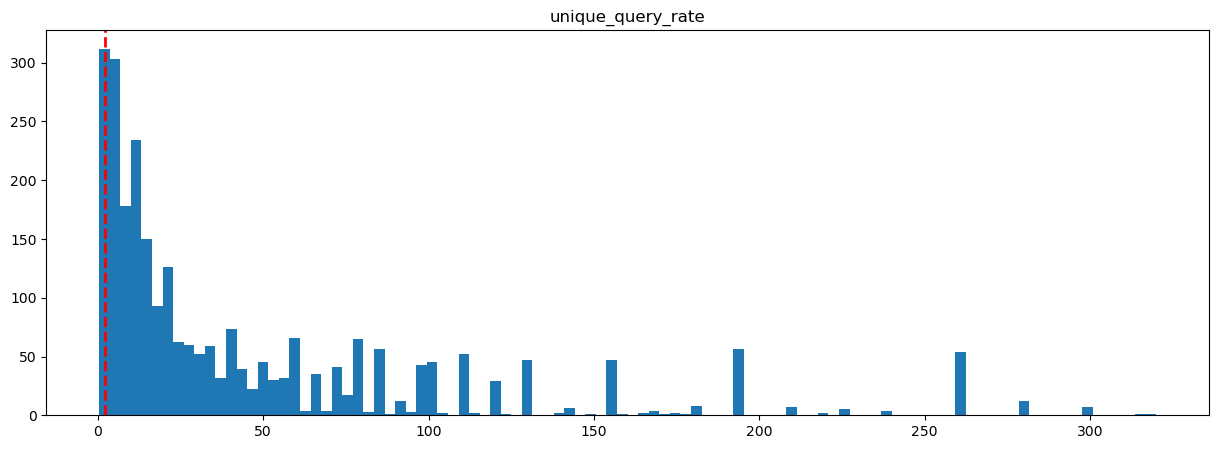

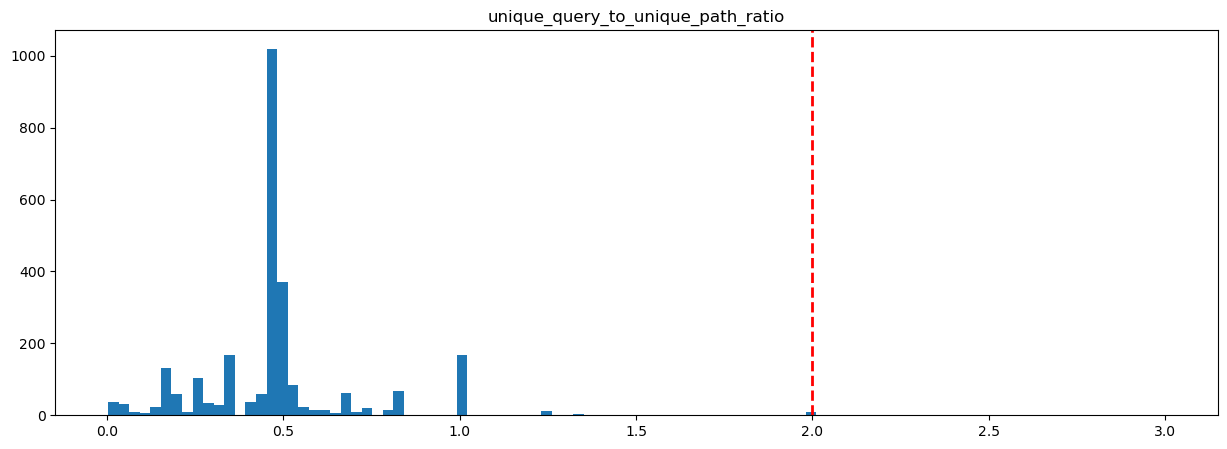

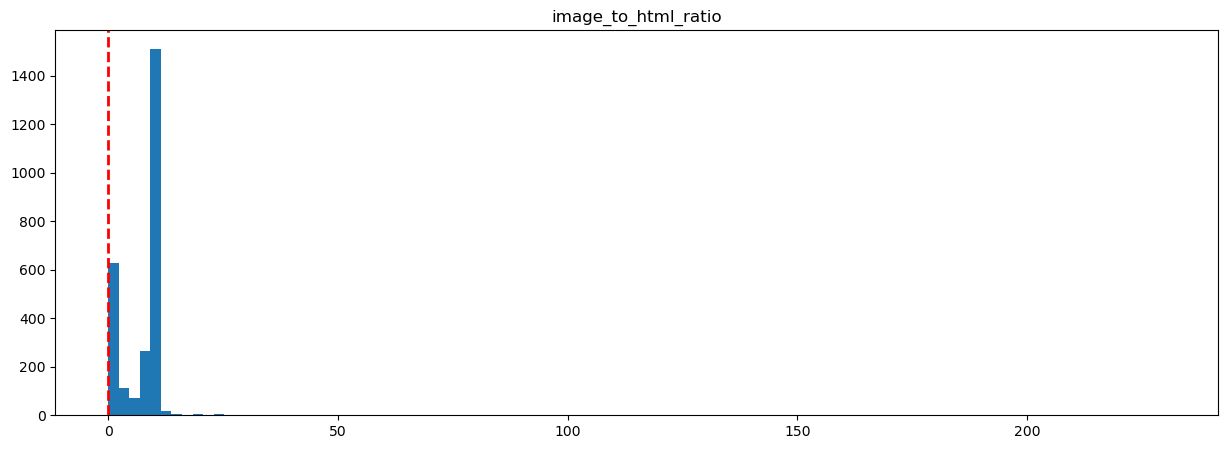

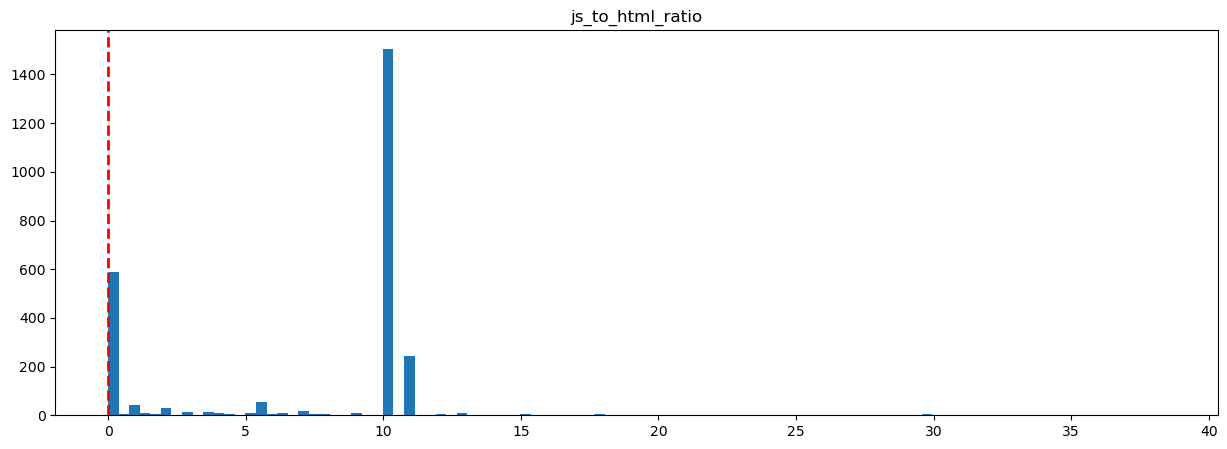

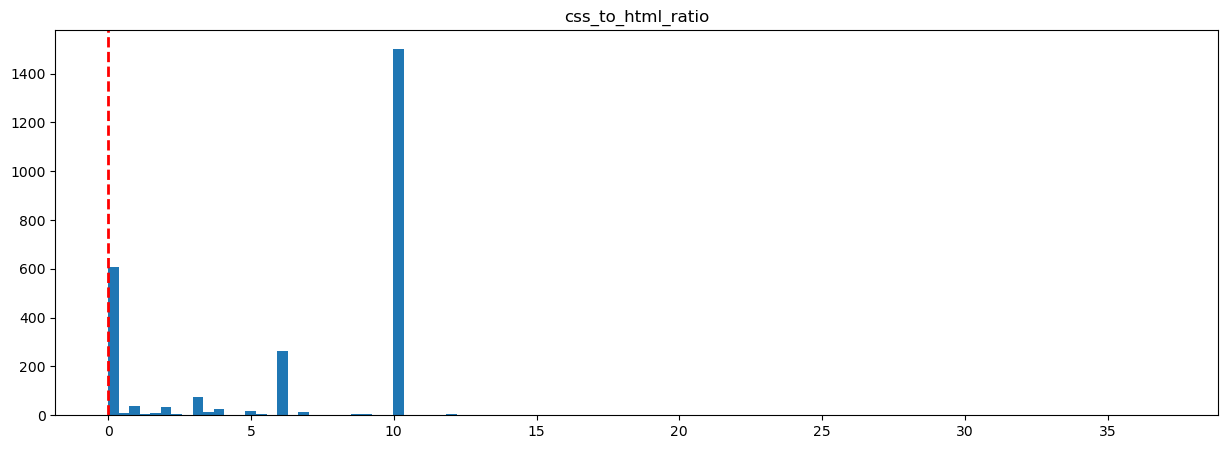

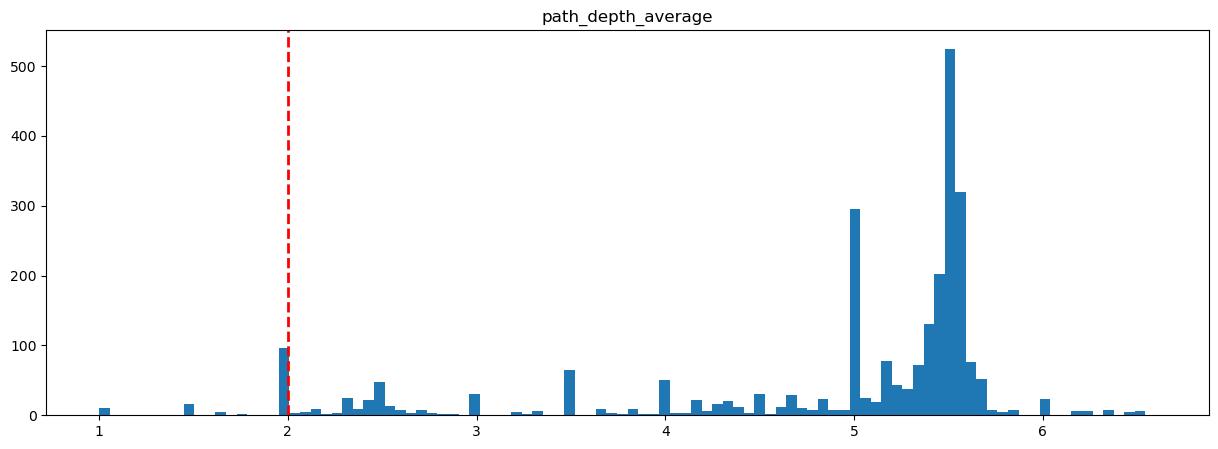

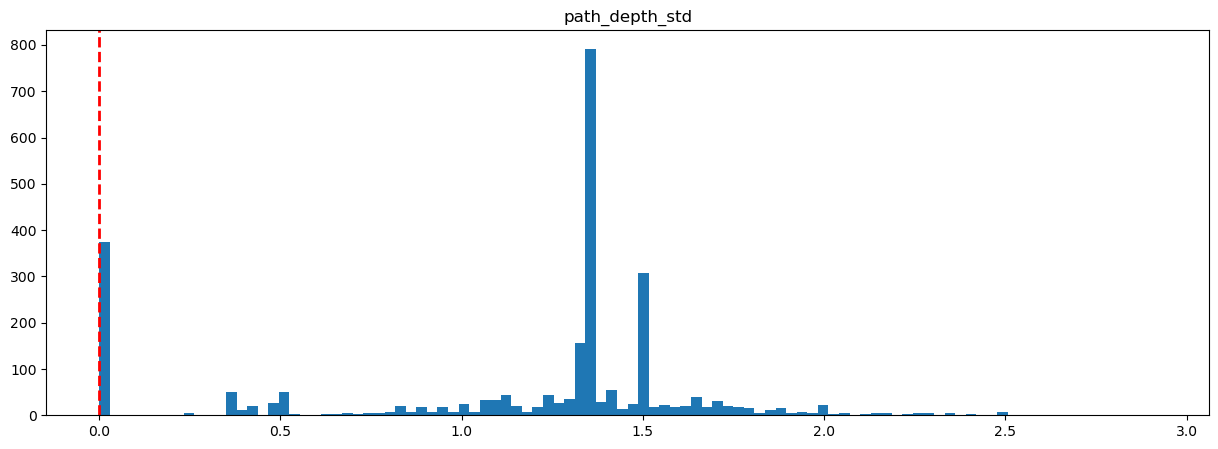

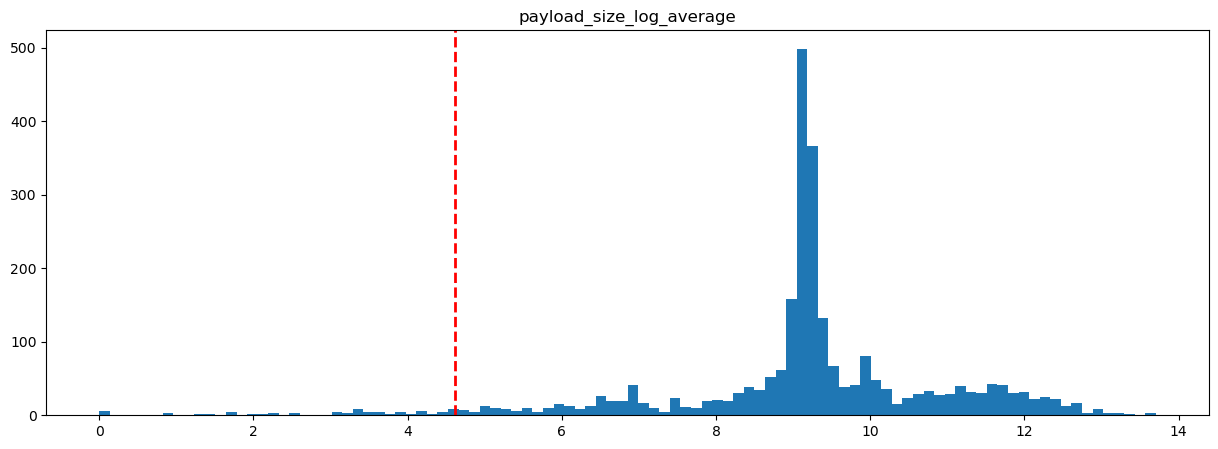

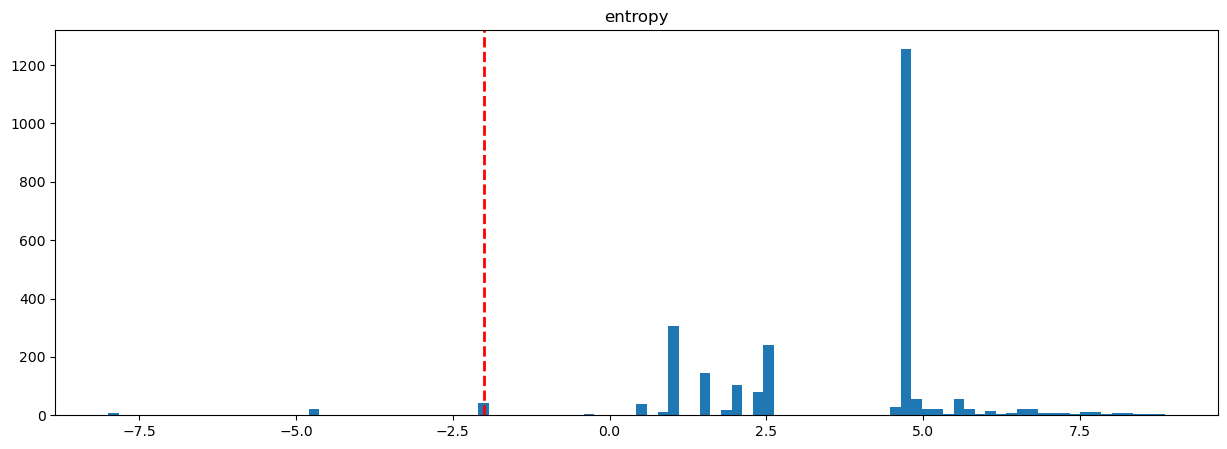

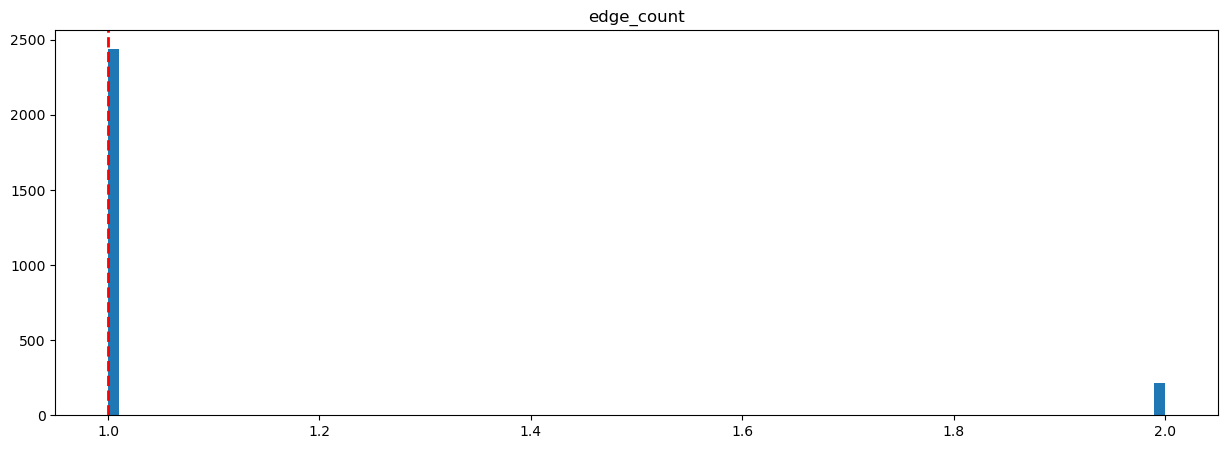

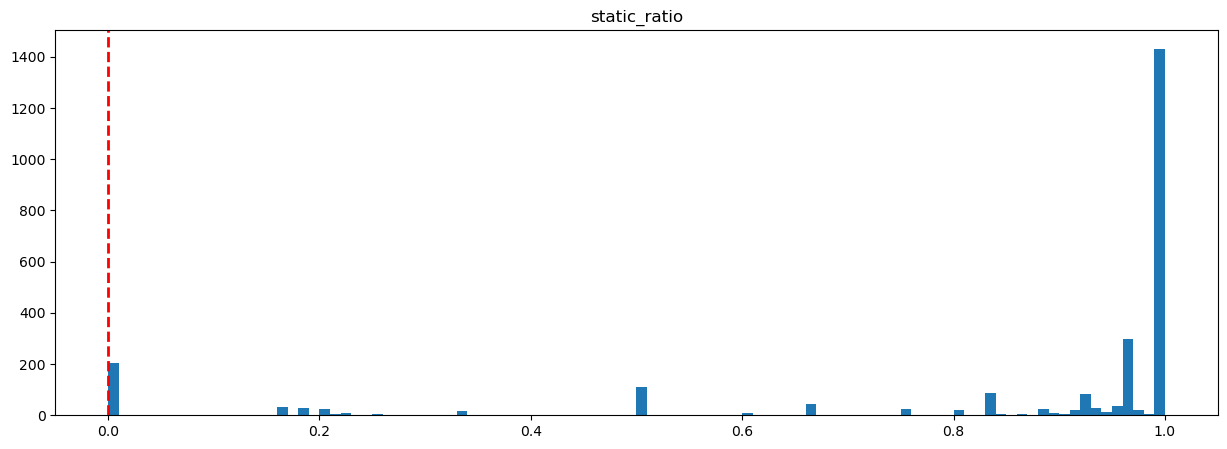

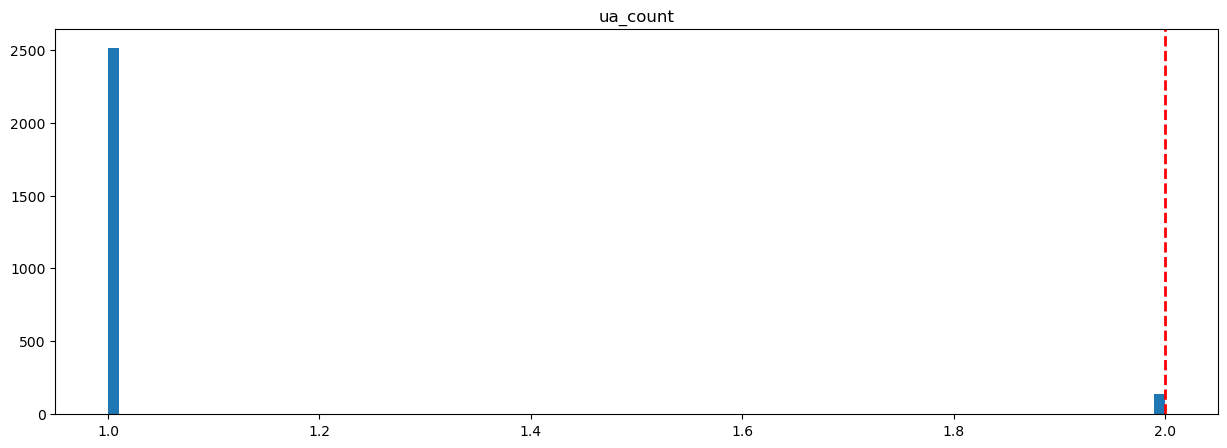

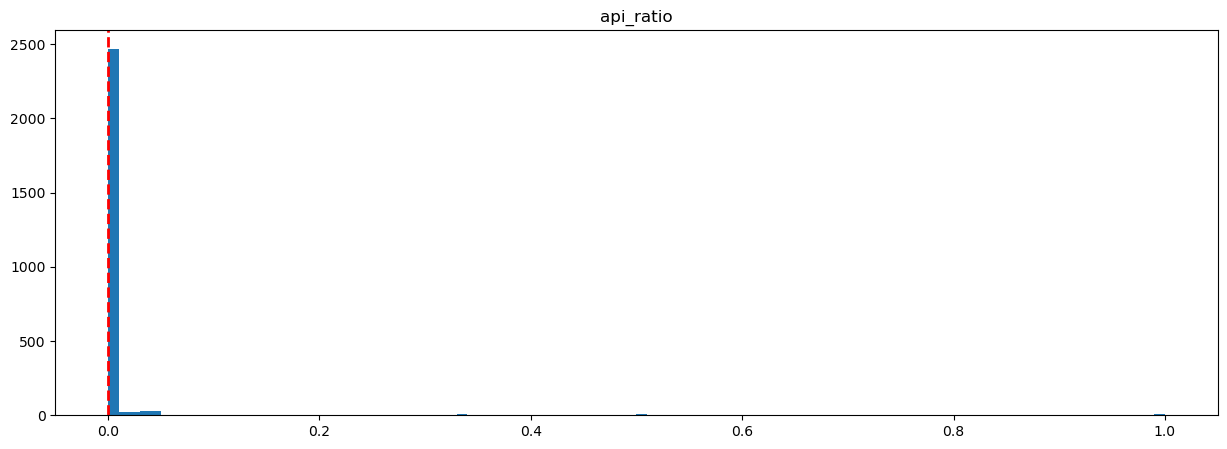

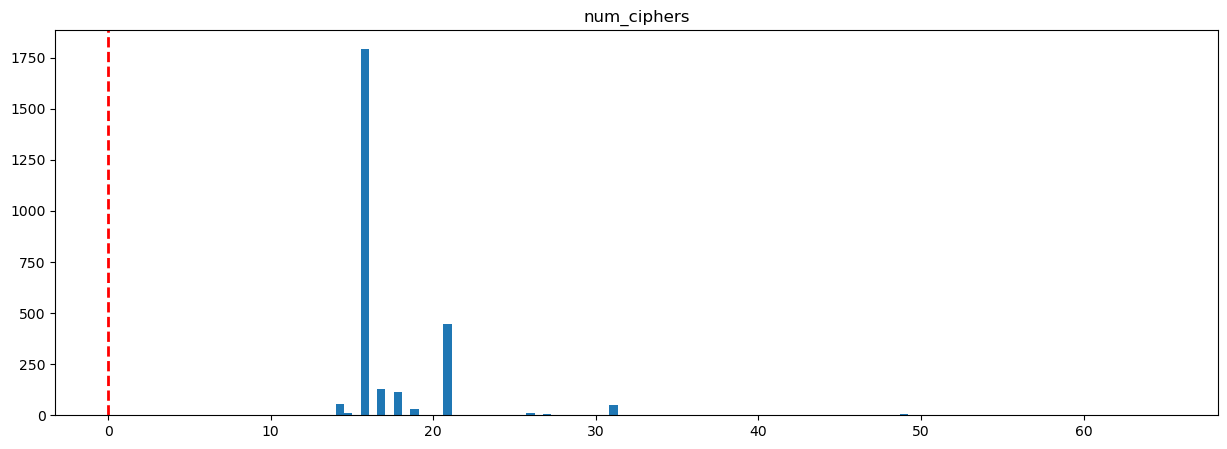

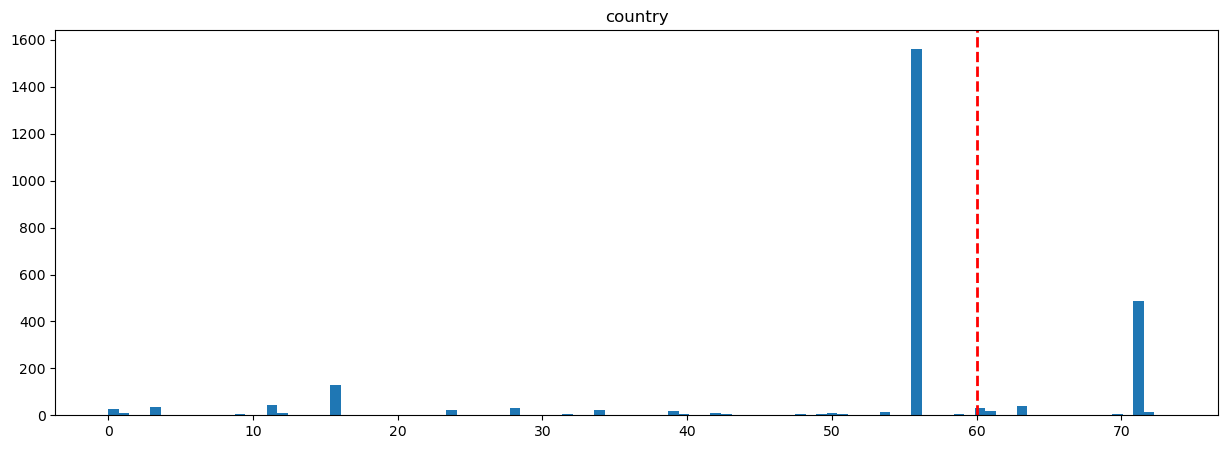

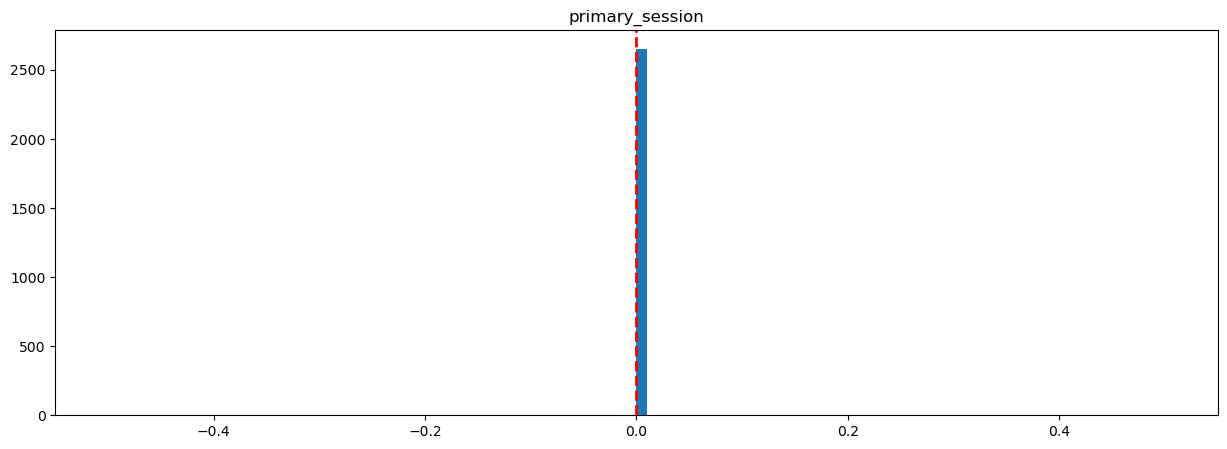

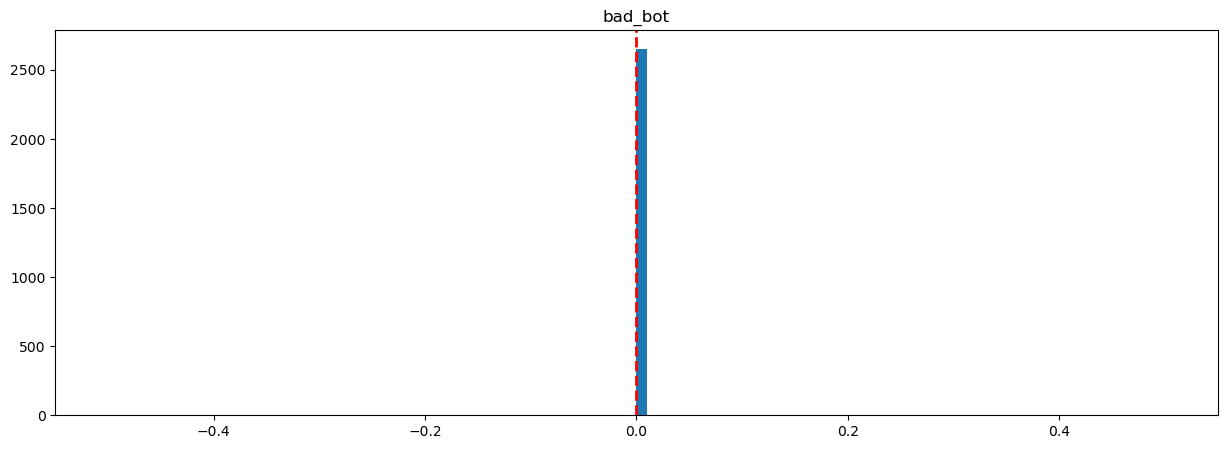

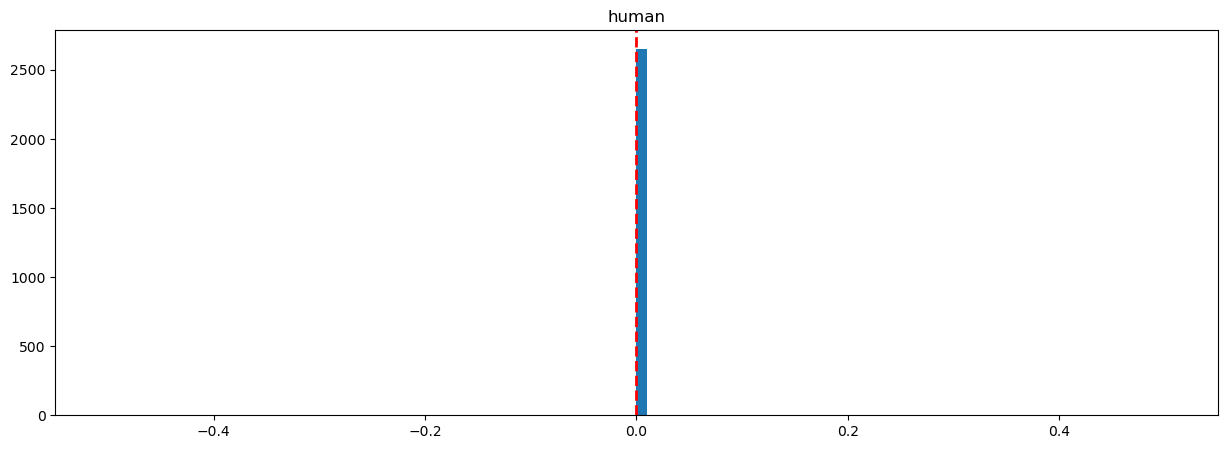

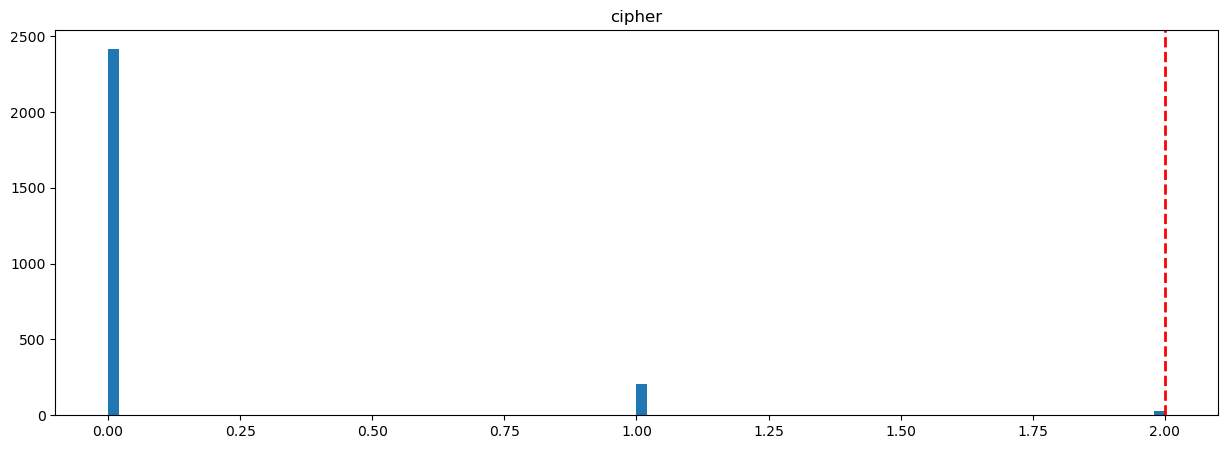

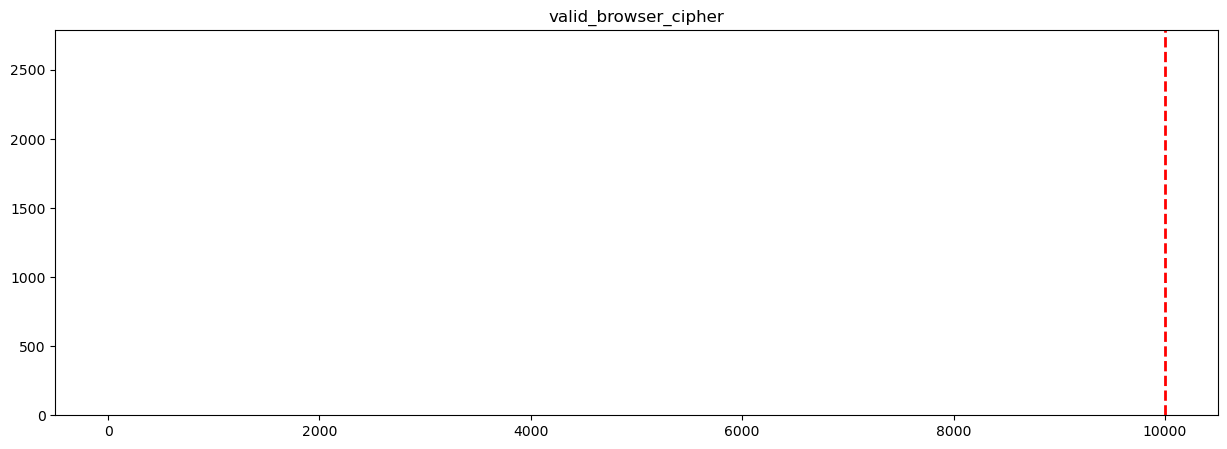

In [145]:
feature_names = fe.get_all_features()
for i in range(len(feature_names)):
    a = np.hstack(Z_train[:,i])
    _ = plt.hist(a, bins=100)  # arguments are passed to np.histogram
    plt.title(feature_names[i])
    plt.axvline(Z[0, i], color='red', linestyle='dashed', linewidth=2)
    plt.show()


In [96]:
ss = []
for s in sessions:
    ss.append(s.get('cipher','xx'))
ss = set(ss)
print(ss)

{'TLS_CHACHA20_POLY1305_SHA256', 'TLS_AES_256_GCM_SHA384', 'TLS_AES_128_GCM_SHA256'}


In [61]:
sessions[-1]['ciphers']

['TLS_AES_128_GCM_SHA256',
 'TLS_AES_128_GCM_SHA256',
 'TLS_AES_128_GCM_SHA256',
 'TLS_AES_128_GCM_SHA256',
 'TLS_AES_256_GCM_SHA384',
 'TLS_CHACHA20_POLY1305_SHA256']

## Automated traffic

In [29]:
sessions2 = read_sessions(host, 1000, model_type=ModelType.BOT)
print('Done.')

Reading from kafka. Host = verafiles.org ... partition = 1
First session start = 2025-03-04 15:21:49 end = 2025-03-04 15:22:04
100 sessions read 2025-03-04 17:29:09 1741109351692
200 sessions read 2025-03-04 19:22:21 1741116144843
300 sessions read 2025-03-04 21:42:50 1741124572989
400 sessions read 2025-03-05 00:19:10 1741133953422
500 sessions read 2025-03-05 02:46:09 1741142770614
600 sessions read 2025-03-05 04:51:48 1741150310056
700 sessions read 2025-03-05 08:25:18 1741163120915
800 sessions read 2025-03-05 10:21:56 1741170119043
900 sessions read 2025-03-05 12:44:29 1741178672539
1.9938500006993611 minutes. Topic offset is too close to the current times...
Done.


In [30]:
scores2, shapley2 = model.transform(sessions2)

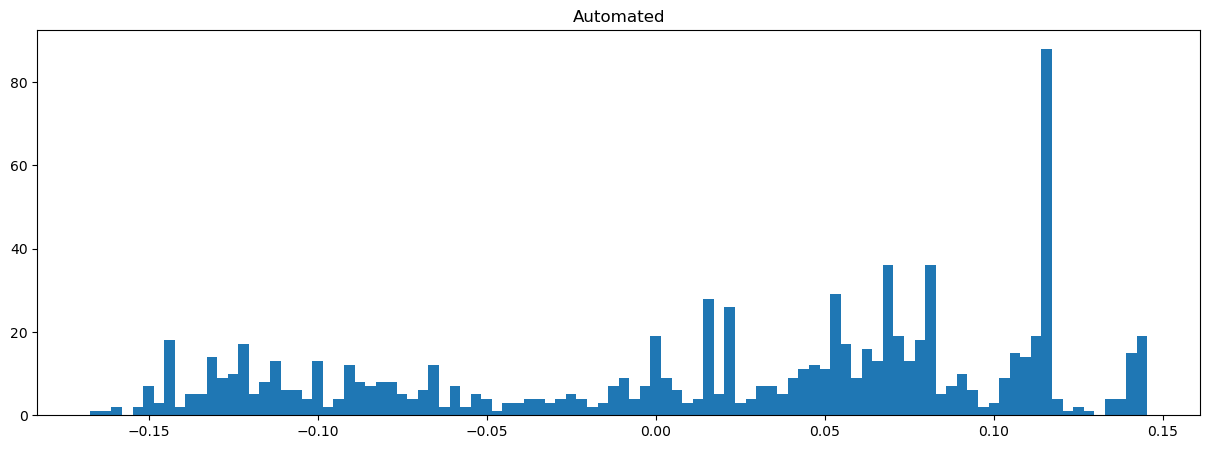

In [31]:
a = np.hstack(scores2)
_ = plt.hist(a, bins=100)  
plt.title('Automated')
plt.show()

In [32]:
print(f'Challenge rate = {challenge_rate(scores2)}')

Challenge rate = 0.34720700985761227


## Session modification

In [138]:
session2 = deepcopy(sessions[3])
session2['requests'] += sessions[10]['requests']
session2['requests'] += sessions[20]['requests']
session2['country'] = 'CA'

print('Isolation Forest')
ts = datetime.now()
score = model.transform([session2])[0]
print(f'timer = {(datetime.now()-ts).total_seconds()}')
print(f'hits={len(session["requests"])}')
print(f'Score = {score}')

Isolation Forest
timer = 0.085669
hits=2
Score = 0.05635794507072106


In [127]:
session2['country']

'UA'